In [97]:
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt


In [98]:
ATTN_DIR = Path("cache/diff_prompts/lastframe_256/run_000")
LAYER = 12
HEAD = 0

# End is exclusive: 0:69 means frames 0-68; None means through the last frame.
FFT_RANGES = [
    {"label": "0-68 first diff", "start": 0, "end": 69},
    {"label": "0-71 first diff", "start": 0, "end": None},
]

SOFTMAX_WINDOW_START = 51
SOFTMAX_WINDOW_END = 72
SOFTMAX_WINDOW_LABEL = "51-71"
SOFTMAX_FFT_RANGES = [
    {"label": f"{SOFTMAX_WINDOW_LABEL} local softmax first diff", "start": 0, "end": None},
]

# Period display range in frames/cycle. Zero frequency is excluded from period plots.
PERIOD_MIN = 2.0
PERIOD_MAX = None

# Response-period selection excludes low-frequency envelope peaks by default.
RESPONSE_PERIOD_MIN = 4.0
RESPONSE_PERIOD_MAX = 18.0
MIN_RESPONSE_CYCLES = 3.0

# ACF verifies FFT candidates; it does not replace FFT period selection.
FFT_TOP_K = 5
ACF_TOL = 2
ACF_MIN = 0.2
NEAR_TIE_RATIO = 1.05
LOW_CYCLE_THRESHOLD = 3.0

# Harmonic folding affects FFT ranking only; raw FFT amplitude remains the plotted/physical value.
HARMONIC_FOLDING_ENABLED = True
HARMONIC_FOLD_MIN_PERIOD = 3.0
HARMONIC_FOLD_MAX_PERIOD_DIVISOR = 6.0
HARMONIC_FOLD_MAX_MULTIPLE = 4
HARMONIC_FOLD_TOL = 0.2
HARMONIC_FOLD_DECAY = 0.5
FFT_DEBUG_TOP_K = 3
SAVE_MAIN_FIGURE = True
MAIN_FIGURE_DPI = 300
MAIN_FIGURE_PATH = Path(f"spectral_analysis_L{LAYER}H{HEAD}_firstdiff_main.png")

REMOVE_DC = True
APPLY_WINDOW = True
SOFTMAX_TEMPERATURE = 1.0


In [99]:
def load_attention(attn_dir, layer, head):
    attn_path = attn_dir / f"layer{layer}.pt"
    payload = torch.load(attn_path, map_location="cpu", weights_only=False)

    per_head = payload["last_frame_attention_per_head"]
    if per_head.ndim != 2:
        raise ValueError(f"Expected per-head attention to be 2D, got shape {tuple(per_head.shape)}")
    if not 0 <= head < per_head.shape[0]:
        raise IndexError(f"HEAD={head} is out of range for {per_head.shape[0]} heads")

    attention = per_head[head].detach().cpu().float().numpy()
    if attention.ndim != 1:
        raise ValueError(f"Expected selected head attention to be 1D, got shape {attention.shape}")

    frame_idx = np.arange(attention.shape[0])
    return attention, frame_idx, attn_path


In [100]:
def normalize_range(start, end, size):
    start = 0 if start is None else start
    end = size if end is None else end
    start_norm = start if start >= 0 else size + start
    end_norm = end if end >= 0 else size + end
    if start_norm < 0 or end_norm > size or start_norm >= end_norm:
        raise ValueError(f"Invalid FFT range {start}:{end} for {size} frames")
    return start, end, start_norm, end_norm


In [101]:
def softmax_1d(values, temperature=1.0):
    if temperature <= 0:
        raise ValueError("SOFTMAX_TEMPERATURE must be positive")
    scaled = values.astype(np.float64) / temperature
    scaled = scaled - np.max(scaled)
    exp_values = np.exp(scaled)
    return exp_values / exp_values.sum()


def local_softmax_1d(values, start, end, temperature=1.0):
    _, _, start_norm, end_norm = normalize_range(start, end, values.size)
    softmax_window = softmax_1d(values[start_norm:end_norm], temperature=temperature)
    softmax_full = np.full(values.shape, np.nan, dtype=np.float64)
    softmax_full[start_norm:end_norm] = softmax_window
    return softmax_full, softmax_window


In [ ]:
def preprocess_signal(sequence, remove_dc=True, apply_window=True):
    if sequence.ndim != 1 or sequence.size < 3:
        raise ValueError(f"First-difference FFT input must be 1D with at least 3 frames, got shape {sequence.shape}")

    signal = np.diff(sequence.astype(np.float64, copy=True))
    if remove_dc:
        signal = signal - signal.mean()
    if apply_window:
        signal = signal * np.hanning(signal.size)
    return signal


In [103]:
def compute_harmonic_folded_spectrum(period, amplitude, signal_size):
    if HARMONIC_FOLD_MAX_PERIOD_DIVISOR is None:
        max_period = np.inf
    elif HARMONIC_FOLD_MAX_PERIOD_DIVISOR <= 0:
        raise ValueError("HARMONIC_FOLD_MAX_PERIOD_DIVISOR must be positive")
    else:
        max_period = signal_size / HARMONIC_FOLD_MAX_PERIOD_DIVISOR

    folded = amplitude.astype(np.float64, copy=True)
    folding_mask = (period >= HARMONIC_FOLD_MIN_PERIOD) & (period <= max_period)
    for idx in np.flatnonzero(folding_mask):
        base = period[idx]
        for multiple in range(2, HARMONIC_FOLD_MAX_MULTIPLE + 1):
            target = multiple * base
            harmonic_idx = int(np.argmin(np.abs(period - target)))
            if abs(period[harmonic_idx] - target) / target < HARMONIC_FOLD_TOL:
                folded[idx] += amplitude[harmonic_idx] * (HARMONIC_FOLD_DECAY ** (multiple - 1))
    return folded


def compute_period_spectrum(sequence):
    signal = preprocess_signal(sequence, remove_dc=REMOVE_DC, apply_window=APPLY_WINDOW)
    freq = np.fft.rfftfreq(signal.size, d=1.0)
    amplitude = np.abs(np.fft.rfft(signal))
    nonzero = freq > 0
    if not np.any(nonzero):
        raise ValueError("FFT produced no nonzero frequency bins")

    freq_bin = np.flatnonzero(nonzero)
    period = 1.0 / freq[nonzero]
    period_amp = amplitude[nonzero]
    order = np.argsort(period)
    period, period_amp, freq_bin = period[order], period_amp[order], freq_bin[order]

    display_mask = np.ones_like(period, dtype=bool)
    if PERIOD_MIN is not None:
        display_mask &= period >= PERIOD_MIN
    if PERIOD_MAX is not None:
        display_mask &= period <= PERIOD_MAX
    if not np.any(display_mask):
        raise ValueError(f"Period display range [{PERIOD_MIN}, {PERIOD_MAX}] contains no FFT bins")

    folded_amp = (
        compute_harmonic_folded_spectrum(period, period_amp, signal.size)
        if HARMONIC_FOLDING_ENABLED
        else period_amp.astype(np.float64, copy=True)
    )

    cycles = signal.size / period
    response_mask = np.ones_like(period, dtype=bool)
    if RESPONSE_PERIOD_MIN is not None:
        response_mask &= period >= RESPONSE_PERIOD_MIN
    if RESPONSE_PERIOD_MAX is not None:
        response_mask &= period <= RESPONSE_PERIOD_MAX
    if MIN_RESPONSE_CYCLES is not None:
        response_mask &= cycles >= MIN_RESPONSE_CYCLES

    global_idx = int(np.argmax(folded_amp))
    if np.any(response_mask):
        candidates = np.flatnonzero(response_mask)
        response_idx = int(candidates[np.argmax(folded_amp[response_mask])])
    else:
        response_idx = None

    def make_candidates(order_indices):
        return [
            {
                "rank": int(rank),
                "period": float(period[idx]),
                "k": int(freq_bin[idx]),
                "amp": float(period_amp[idx]),
                "folded_score": float(folded_amp[idx]),
                "cycles": float(cycles[idx]),
            }
            for rank, idx in enumerate(order_indices, start=1)
        ]

    pool = np.flatnonzero(display_mask)
    raw_top = pool[np.argsort(period_amp[display_mask])[::-1]][:FFT_TOP_K]
    folded_top = pool[np.argsort(folded_amp[display_mask])[::-1]][:FFT_TOP_K]
    folded_candidates = make_candidates(folded_top)

    return {
        "period": period,
        "period_amplitude": period_amp,
        "folded_period_amplitude": folded_amp,
        "freq_bin": freq_bin,
        "cycles": cycles,
        "display_mask": display_mask,
        "raw_fft_top_candidates": make_candidates(raw_top),
        "folded_fft_top_candidates": folded_candidates,
        "fft_top_candidates": folded_candidates,
        "global_period": float(period[global_idx]),
        "global_k": int(freq_bin[global_idx]),
        "global_amp": float(period_amp[global_idx]),
        "global_folded_score": float(folded_amp[global_idx]),
        "response_period": np.nan if response_idx is None else float(period[response_idx]),
        "response_k": None if response_idx is None else int(freq_bin[response_idx]),
        "response_amp": np.nan if response_idx is None else float(period_amp[response_idx]),
        "response_folded_score": np.nan if response_idx is None else float(folded_amp[response_idx]),
        "signal_size": signal.size,
    }


In [104]:
def compute_acf(sequence, max_lag):
    values = np.asarray(sequence, dtype=np.float64)
    if values.ndim != 1 or values.size < 2:
        raise ValueError(f"ACF input must be 1D with at least 2 frames, got shape {values.shape}")

    max_lag = int(min(max_lag, values.size - 1))
    if max_lag < 0:
        raise ValueError("max_lag must be non-negative")

    centered = values - values.mean()
    denom = float(np.dot(centered, centered))
    lags = np.arange(max_lag + 1)
    acf_values = np.zeros(max_lag + 1, dtype=np.float64)
    if denom <= np.finfo(np.float64).eps:
        acf_values[0] = 1.0
        return lags, acf_values

    for lag in lags:
        acf_values[lag] = np.dot(centered[: values.size - lag], centered[lag:]) / denom
    return lags, acf_values


def find_acf_peaks(acf_values, min_value=ACF_MIN):
    values = np.asarray(acf_values, dtype=np.float64)
    peaks = []
    for lag in range(1, values.size - 1):
        v = values[lag]
        if v >= min_value and v >= values[lag - 1] and v >= values[lag + 1]:
            peaks.append({"lag": int(lag), "acf": float(v)})
    return peaks


def validate_fft_candidates_with_acf(sequence, spectrum):
    lags, acf_values = compute_acf(sequence, max_lag=len(sequence) - 1)
    acf_peaks = find_acf_peaks(acf_values, min_value=ACF_MIN)
    acf_first_peak_lag = acf_peaks[0]["lag"] if acf_peaks else None

    top_candidates = spectrum["fft_top_candidates"]
    top1_top2_ratio = (
        top_candidates[0]["folded_score"] / top_candidates[1]["folded_score"]
        if len(top_candidates) >= 2 and top_candidates[1]["folded_score"] > 0
        else np.nan
    )
    near_tie = bool(np.isfinite(top1_top2_ratio) and top1_top2_ratio < NEAR_TIE_RATIO)

    def entry_for_k(k):
        if k is None:
            return None
        matches = np.flatnonzero(spectrum["freq_bin"] == k)
        if matches.size == 0:
            return None
        idx = int(matches[0])
        return {
            "period": float(spectrum["period"][idx]),
            "k": int(k),
            "amp": float(spectrum["period_amplitude"][idx]),
            "folded_score": float(spectrum["folded_period_amplitude"][idx]),
            "cycles": float(spectrum["cycles"][idx]),
        }

    candidate_map = {}
    def add(source, entry, rank=None):
        if entry is None or not np.isfinite(entry["period"]):
            return
        row = candidate_map.setdefault(entry["k"], {**entry, "source": [], "rank": rank})
        row["source"].append(source)
        if rank is not None:
            row["rank"] = rank

    add("response", entry_for_k(spectrum.get("response_k")))
    add("global", entry_for_k(spectrum.get("global_k")))
    for c in top_candidates:
        add(f"top{c['rank']}", c, rank=c["rank"])

    validations = []
    for row in candidate_map.values():
        lag = int(round(row["period"]))
        lo = max(1, lag - ACF_TOL)
        hi = min(len(acf_values) - 1, lag + ACF_TOL)
        local_peaks = [p for p in acf_peaks if lo <= p["lag"] <= hi]
        if local_peaks:
            best = max(local_peaks, key=lambda p: p["acf"])
            best_lag, best_acf = best["lag"], best["acf"]
            has_confirming = best_acf >= ACF_MIN
        elif lo <= hi:
            window = acf_values[lo : hi + 1]
            offset = int(np.argmax(window))
            best_lag, best_acf = int(lo + offset), float(window[offset])
            has_confirming = False
        else:
            best_lag, best_acf, has_confirming = None, np.nan, False

        if row["cycles"] < LOW_CYCLE_THRESHOLD:
            status = "low_cycle_envelope"
        elif has_confirming:
            status = "acf_confirmed"
        elif near_tie and row.get("rank") in (1, 2):
            status = "near_tie"
        else:
            status = "weak_or_unconfirmed"

        validations.append({
            **row,
            "source": ",".join(row["source"]),
            "lag": lag,
            "acf": float(acf_values[lag]) if 0 <= lag < len(acf_values) else np.nan,
            "best_lag": best_lag,
            "best_acf": float(best_acf) if np.isfinite(best_acf) else np.nan,
            "status": status,
        })

    validations.sort(key=lambda r: (r["rank"] is None, r["rank"] or 999, -r["folded_score"]))
    sources = lambda row: row["source"].split(",")
    response_status = next((r["status"] for r in validations if "response" in sources(r)), None)
    global_status = next((r["status"] for r in validations if "global" in sources(r)), None)

    return {
        "acf_lag": lags,
        "acf_value": acf_values,
        "acf_first_peak_lag": acf_first_peak_lag,
        "acf_validations": validations,
        "period_status": {
            "top1_top2_ratio": float(top1_top2_ratio) if np.isfinite(top1_top2_ratio) else np.nan,
            "near_tie": near_tie,
            "response_status": response_status,
            "global_status": global_status,
            "low_cycle_count": int(sum(r["status"] == "low_cycle_envelope" for r in validations)),
        },
    }


In [105]:
def analyze_fft_ranges(values, fft_ranges):
    results = []
    for cfg in fft_ranges:
        start, end, start_norm, end_norm = normalize_range(cfg.get("start"), cfg.get("end"), values.size)
        window_values = values[start_norm:end_norm]
        spectrum = compute_period_spectrum(window_values)
        acf_validation = validate_fft_candidates_with_acf(window_values, spectrum)
        results.append({**cfg, **spectrum, **acf_validation, "start_norm": start_norm, "end_norm": end_norm})
    return results


In [106]:
def _format_float(value, digits=3):
    return "nan" if value is None or not np.isfinite(value) else f"{value:.{digits}f}"


def _format_optional_int(value):
    return "none" if value is None else str(int(value))


def _print_fft_candidate_table(title, candidates):
    print(title)
    print("      rank   k   period      amp folded_score  cycles")
    for candidate in candidates[:FFT_DEBUG_TOP_K]:
        print(
            f"      {candidate['rank']:>4d} {candidate['k']:>3d} "
            f"{candidate['period']:>8.3f} {candidate['amp']:>8.4g} "
            f"{candidate['folded_score']:>12.4g} {candidate['cycles']:>7.2f}"
        )


def print_results(title, results):
    print(title)
    for result in results:
        inclusive_end = result["end_norm"] - 1
        print(
            f"  {result['label']}: frames {result['start_norm']}-{inclusive_end} "
            f"({result['signal_size']} frames), "
            f"global={result['global_period']:.3f} frames "
            f"(amp={result['global_amp']:.6g}, folded_score={result['global_folded_score']:.6g}), "
            f"response={result['response_period']:.3f} frames "
            f"(amp={result['response_amp']:.6g}, folded_score={result['response_folded_score']:.6g})"
        )
        _print_fft_candidate_table("    Raw FFT top candidates:", result["raw_fft_top_candidates"])
        _print_fft_candidate_table("    Folded FFT top candidates:", result["folded_fft_top_candidates"])
        status = result["period_status"]
        ratio = status["top1_top2_ratio"]
        ratio_text = "nan" if not np.isfinite(ratio) else f"{ratio:.3f}"
        print(
            f"    ACF first peak lag={_format_optional_int(result['acf_first_peak_lag'])}; "
            f"top1/top2_ratio={ratio_text}; "
            f"near_tie={status['near_tie']}; "
            f"response_status={status['response_status']}; "
            f"global_status={status['global_status']}; "
            f"low_cycle_count={status['low_cycle_count']}"
        )
        print("    FFT candidates verified by ACF:")
        print("      source           k   period      amp folded_score  cycles  lag     acf  best_lag best_acf  status")
        for row in result["acf_validations"]:
            best_lag = _format_optional_int(row["best_lag"])
            print(
                f"      {row['source']:<14} {row['k']:>3d} "
                f"{row['period']:>8.3f} {row['amp']:>8.4g} {row['folded_score']:>12.4g} {row['cycles']:>7.2f} "
                f"{row['lag']:>4d} {_format_float(row['acf'], 3):>7} "
                f"{best_lag:>8} {_format_float(row['best_acf'], 3):>8}  {row['status']}"
            )


In [107]:
def print_attention_diagnostics(
    raw_attention,
    softmax_full,
    softmax_window,
    softmax_window_start,
    softmax_window_label,
    tail_start=60,
    top_k=10,
):
    raw_top = np.argsort(raw_attention)[-top_k:][::-1]
    softmax_top = np.argsort(softmax_window)[-top_k:][::-1]
    softmax_window_end = softmax_window_start + softmax_window.size

    print("Attention diagnostics")
    print(
        f"  raw: sum={raw_attention.sum():.6g}, min={raw_attention.min():.6g}, "
        f"max={raw_attention.max():.6g} at frame {int(np.argmax(raw_attention))}"
    )
    print(
        f"  local softmax window: frames {softmax_window_label}; "
        f"window sum={softmax_window.sum():.6g} (normalization is local, not over all {raw_attention.size} frames), "
        f"min={softmax_window.min():.6g}, max={softmax_window.max():.6g} "
        f"at frame {int(softmax_window_start + np.argmax(softmax_window))}"
    )
    print(f"  raw frames {tail_start}-{raw_attention.size - 1}:")
    print("   ", np.array2string(raw_attention[tail_start:], precision=6, suppress_small=False))
    print(f"  local softmax frames {softmax_window_start}-{softmax_window_end - 1}:")
    print("   ", np.array2string(softmax_window, precision=6, suppress_small=False))
    print(f"  full softmax plot vector NaN outside frames {softmax_window_label}; nansum={np.nansum(softmax_full):.6g}")
    print("  top raw frames:")
    for idx in raw_top:
        print(f"    frame {int(idx):2d}: {raw_attention[idx]:.6g}")
    print("  top local softmax frames:")
    for idx in softmax_top:
        frame = int(softmax_window_start + idx)
        print(f"    frame {frame:2d}: {softmax_window[idx]:.6g}")


In [108]:
def plot_attention_and_spectra(
    frame_idx,
    raw_attention,
    softmax_attention,
    raw_results,
    softmax_results,
    softmax_window_start,
    softmax_window_end,
    softmax_window_label,
    save_path=None,
    save_dpi=300,
):
    fig, axes = plt.subplots(3, 2, figsize=(16, 12), constrained_layout=True)
    ax_raw_time, ax_softmax_time = axes[0]
    ax_raw_period, ax_softmax_period = axes[1]
    ax_raw_acf, ax_softmax_acf = axes[2]
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax_raw_time.plot(frame_idx, raw_attention, marker="o", linewidth=1.5, markersize=3, color="black", label="Raw attention")
    ax_softmax_time.plot(frame_idx, softmax_attention, marker="o", linewidth=1.5, markersize=3, color="black", label=f"Local softmax {softmax_window_label}")

    for idx, result in enumerate(raw_results):
        color = colors[idx % len(colors)]
        ax_raw_time.axvspan(
            result["start_norm"] - 0.5,
            result["end_norm"] - 0.5,
            color=color,
            alpha=0.12,
            label=f"FFT {result['label']}",
        )

    ax_softmax_time.axvspan(
        softmax_window_start - 0.5,
        softmax_window_end - 0.5,
        color=colors[0],
        alpha=0.12,
        label=f"Local window {softmax_window_label}",
    )

    for ax, ylabel, title in [
        (ax_raw_time, "Attention", "Raw selected-head attention"),
        (ax_softmax_time, "Softmax(attention)", "Local softmax selected-head attention"),
    ]:
        ax.set_xlabel("Frame")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")

    for ax, results, title in [
        (ax_raw_period, raw_results, "Raw period spectrum + folded score"),
        (ax_softmax_period, softmax_results, "Local softmax period spectrum + folded score"),
    ]:
        for idx, result in enumerate(results):
            color = colors[idx % len(colors)]
            mask = result["display_mask"]
            ax.plot(
                result["period"][mask],
                result["period_amplitude"][mask],
                marker="o",
                linewidth=1.5,
                markersize=3,
                color=color,
                label=f"{result['label']} raw amp | response {result['response_period']:.2f} | global {result['global_period']:.2f}",
            )
            ax.plot(
                result["period"][mask],
                result["folded_period_amplitude"][mask],
                marker="x",
                linestyle="-.",
                linewidth=1.2,
                markersize=3,
                color=color,
                alpha=0.75,
                label=f"{result['label']} folded score",
            )
            if np.isfinite(result["global_period"]):
                ax.axvline(result["global_period"], color=color, linestyle=":", linewidth=1.0, alpha=0.6)
            if np.isfinite(result["response_period"]):
                ax.axvline(result["response_period"], color=color, linestyle="--", linewidth=1.2, alpha=0.9)

        ax.set_xlabel("Period (frames/cycle)")
        ax.set_ylabel("Raw FFT amp / folded score")
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")

    status_styles = {
        "acf_confirmed": {"color": "tab:green", "marker": "o", "label": "ACF confirmed"},
        "low_cycle_envelope": {"color": "tab:orange", "marker": "s", "label": "Low-cycle envelope"},
        "near_tie": {"color": "tab:purple", "marker": "D", "label": "Near FFT tie"},
        "weak_or_unconfirmed": {"color": "0.45", "marker": "x", "label": "Weak/unconfirmed"},
    }

    for ax, results, title in [
        (ax_raw_acf, raw_results, "Raw ACF validation"),
        (ax_softmax_acf, softmax_results, "Local softmax ACF validation"),
    ]:
        used_labels = set()
        for idx, result in enumerate(results):
            color = colors[idx % len(colors)]
            lags = result["acf_lag"]
            acf_values = result["acf_value"]
            ax.plot(lags[1:], acf_values[1:], linewidth=1.5, color=color, label=f"{result['label']} ACF")
            first_peak = result["acf_first_peak_lag"]
            if first_peak is not None:
                ax.axvline(first_peak, color=color, linestyle="--", linewidth=1.0, alpha=0.7)
                ax.scatter(
                    [first_peak],
                    [acf_values[first_peak]],
                    color=color,
                    marker="^",
                    s=45,
                    zorder=4,
                    label=f"{result['label']} first peak",
                )

            for row in result["acf_validations"]:
                style = status_styles[row["status"]]
                label = style["label"] if style["label"] not in used_labels else None
                if label is not None:
                    used_labels.add(style["label"])
                ax.axvline(row["lag"], color=style["color"], linestyle=":", linewidth=0.9, alpha=0.45)
                if row["best_lag"] is not None and np.isfinite(row["best_acf"]):
                    ax.scatter(
                        [row["best_lag"]],
                        [row["best_acf"]],
                        color=style["color"],
                        marker=style["marker"],
                        s=36,
                        zorder=5,
                        label=label,
                    )

        ax.axhline(ACF_MIN, color="0.25", linestyle="--", linewidth=0.9, alpha=0.55, label=f"ACF min {ACF_MIN:g}")
        ax.set_xlabel("Lag (frames)")
        ax.set_ylabel("ACF")
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")

    fig.suptitle(
        f"Layer {LAYER}, Head {HEAD} | FFT solid=raw, dash-dot=folded score; vertical dashed=response, dotted=global",
        fontsize=13,
    )
    if save_path is not None:
        fig.savefig(save_path, dpi=save_dpi, bbox_inches="tight")
        print(f"Saved main figure to {save_path}")
    plt.show()


In [ ]:
attention, frame_idx, attn_path = load_attention(ATTN_DIR, LAYER, HEAD)
softmax_attention, softmax_window = local_softmax_1d(
    attention,
    SOFTMAX_WINDOW_START,
    SOFTMAX_WINDOW_END,
    temperature=SOFTMAX_TEMPERATURE,
)

raw_results = analyze_fft_ranges(attention, FFT_RANGES)
softmax_results = analyze_fft_ranges(softmax_window, SOFTMAX_FFT_RANGES)

print(f"Loaded {attn_path}: layer={LAYER}, head={HEAD}, frames={attention.size}, preprocess=first_difference")
print_attention_diagnostics(
    attention,
    softmax_attention,
    softmax_window,
    SOFTMAX_WINDOW_START,
    SOFTMAX_WINDOW_LABEL,
)
print_results("Raw attention", raw_results)
print_results("Local softmax attention", softmax_results)

plot_attention_and_spectra(
    frame_idx,
    attention,
    softmax_attention,
    raw_results,
    softmax_results,
    SOFTMAX_WINDOW_START,
    SOFTMAX_WINDOW_END,
    SOFTMAX_WINDOW_LABEL,
    save_path=MAIN_FIGURE_PATH if SAVE_MAIN_FIGURE else None,
    save_dpi=MAIN_FIGURE_DPI,
)


In [110]:
import csv
from collections import Counter


BATCH_PROMPTS_DIR = Path("cache/diff_prompts/lastframe_256")
BATCH_NUM_PROMPTS = 256
BATCH_NUM_LAYERS = 30
BATCH_NUM_HEADS = 12
BATCH_RANGE_LABEL = "0-68"
BATCH_RANGE_START = 0
BATCH_RANGE_END = 69
HEAD_PERIOD_HOMOLOGY_CSV_PATH = Path("cache/head_period_homology_256_firstdiff_folded_top1_0_68.csv")
HEAD_PERIOD_HOMOLOGY_FIGURE_PATH = Path("cache/head_period_homology_256_firstdiff_folded_top1_0_68.png")
HEAD_PERIOD_HOMOLOGY_SCATTER_FIGURE_PATH = Path("cache/head_period_homology_256_firstdiff_folded_top1_0_68_scatter.png")


def compute_head_period_homology_256():
    prompt_dirs = [BATCH_PROMPTS_DIR / f"run_{i:03d}" for i in range(BATCH_NUM_PROMPTS)]
    missing = [p for p in prompt_dirs if not p.is_dir()]
    if missing:
        preview = ", ".join(str(p) for p in missing[:5])
        raise FileNotFoundError(f"Missing {len(missing)} prompt directories under {BATCH_PROMPTS_DIR}: {preview}")

    periods = np.full((BATCH_NUM_LAYERS, BATCH_NUM_HEADS, BATCH_NUM_PROMPTS), np.nan, dtype=np.float64)
    errors = []

    for prompt_idx, prompt_dir in enumerate(prompt_dirs):
        if prompt_idx == 0 or (prompt_idx + 1) % 32 == 0 or prompt_idx + 1 == BATCH_NUM_PROMPTS:
            print(f"Processing prompt {prompt_idx + 1}/{BATCH_NUM_PROMPTS}: {prompt_dir.name}")
        for layer in range(BATCH_NUM_LAYERS):
            attn_path = prompt_dir / f"layer{layer}.pt"
            try:
                payload = torch.load(attn_path, map_location="cpu", weights_only=False)
                per_head = payload["last_frame_attention_per_head"]
                if per_head.ndim != 2 or per_head.shape[0] < BATCH_NUM_HEADS:
                    raise ValueError(f"Unexpected per-head shape {tuple(per_head.shape)}")
                per_head_np = per_head[:BATCH_NUM_HEADS].detach().cpu().float().numpy()
                for head in range(BATCH_NUM_HEADS):
                    sequence = per_head_np[head, BATCH_RANGE_START:BATCH_RANGE_END]
                    spectrum = compute_period_spectrum(sequence)
                    periods[layer, head, prompt_idx] = float(spectrum["folded_fft_top_candidates"][0]["period"])
            except Exception as exc:
                errors.append({"prompt_idx": prompt_idx, "layer": layer, "path": str(attn_path), "error": repr(exc)})

    return summarize_head_periods(periods), errors, periods


def summarize_head_periods(periods):
    rows = []
    num_layers, num_heads, _ = periods.shape
    for layer in range(num_layers):
        for head in range(num_heads):
            valid = periods[layer, head][np.isfinite(periods[layer, head])]
            if valid.size:
                counts = Counter(float(v) for v in valid)
                dominant_period, dominant_count = max(counts.items(), key=lambda kv: (kv[1], -kv[0]))
                p_min, p_max = float(np.min(valid)), float(np.max(valid))
                p_q25, p_q75 = float(np.quantile(valid, 0.25)), float(np.quantile(valid, 0.75))
                stats = {
                    "n_prompts": int(valid.size),
                    "period_mean": float(np.mean(valid)),
                    "period_min": p_min,
                    "period_max": p_max,
                    "period_std": float(np.std(valid)),
                    "period_q25": p_q25,
                    "period_q75": p_q75,
                    "period_iqr": p_q75 - p_q25,
                    "period_range": p_max - p_min,
                    "dominant_period": float(dominant_period),
                    "dominant_period_count": int(dominant_count),
                }
            else:
                stats = {k: (0 if k in ("n_prompts", "dominant_period_count") else np.nan)
                         for k in ("n_prompts", "period_mean", "period_min", "period_max", "period_std",
                                   "period_q25", "period_q75", "period_iqr", "period_range",
                                   "dominant_period", "dominant_period_count")}
            rows.append({"layer": layer, "head": head, "head_index": layer * num_heads + head, **stats})
    return rows


def write_head_period_homology_csv(rows, csv_path=HEAD_PERIOD_HOMOLOGY_CSV_PATH):
    csv_path = Path(csv_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    with csv_path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)
    print(f"Wrote {len(rows)} rows to {csv_path}")


def _add_layer_grid(ax):
    for layer in range(BATCH_NUM_LAYERS + 1):
        ax.axvline(layer * BATCH_NUM_HEADS - 0.5, color="0.72", linewidth=0.7, alpha=0.75, zorder=0)
    layer_centers = [layer * BATCH_NUM_HEADS + (BATCH_NUM_HEADS - 1) / 2 for layer in range(BATCH_NUM_LAYERS)]
    top_ax = ax.secondary_xaxis("top")
    top_ax.set_xticks(layer_centers)
    top_ax.set_xticklabels([f"L{layer}" for layer in range(BATCH_NUM_LAYERS)], fontsize=8)
    top_ax.tick_params(axis="x", length=0, pad=3)
    top_ax.set_xlabel("Layer")
    ax.set_xlim(-0.5, BATCH_NUM_LAYERS * BATCH_NUM_HEADS - 0.5)


def plot_head_period_homology(rows, figure_path=HEAD_PERIOD_HOMOLOGY_FIGURE_PATH, dpi=300):
    x = np.array([r["head_index"] for r in rows], dtype=np.float64)
    mean = np.array([r["period_mean"] for r in rows], dtype=np.float64)
    period_min = np.array([r["period_min"] for r in rows], dtype=np.float64)
    period_max = np.array([r["period_max"] for r in rows], dtype=np.float64)
    std = np.array([r["period_std"] for r in rows], dtype=np.float64)

    fig, ax = plt.subplots(figsize=(22, 7), constrained_layout=True)
    color = "#1f4e79"
    ax.fill_between(x, period_min, period_max, color=color, alpha=0.16, label="min-max")
    ax.plot(x, mean - std, color=color, linestyle="--", linewidth=1.0, alpha=0.65, label="mean +/- std")
    ax.plot(x, mean + std, color=color, linestyle="--", linewidth=1.0, alpha=0.65)
    ax.plot(x, mean, color=color, marker="o", markersize=3.2, linewidth=1.6, label="mean")

    _add_layer_grid(ax)
    ax.set_xlabel("Head index (layer * 12 + head)")
    ax.set_ylabel("Period (frames/cycle)")
    ax.set_title("All-head period homology across 256 prompts | first diff | folded FFT top1 | frames 0-68")
    ax.grid(True, axis="y", alpha=0.28)
    ax.legend(loc="upper right")

    figure_path = Path(figure_path)
    figure_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure to {figure_path}")
    plt.show()


def plot_head_period_homology_scatter(rows, periods, figure_path=HEAD_PERIOD_HOMOLOGY_SCATTER_FIGURE_PATH, dpi=300):
    expected_shape = (BATCH_NUM_LAYERS, BATCH_NUM_HEADS, BATCH_NUM_PROMPTS)
    if periods.shape != expected_shape:
        raise AssertionError(f"Expected periods shape {expected_shape}, got {periods.shape}")

    x = np.array([r["head_index"] for r in rows], dtype=np.float64)
    flat = periods.reshape(BATCH_NUM_LAYERS * BATCH_NUM_HEADS, BATCH_NUM_PROMPTS)
    prompt_offsets = np.linspace(-0.35, 0.35, BATCH_NUM_PROMPTS)
    scatter_x = (x[:, None] + prompt_offsets[None, :]).reshape(-1)
    scatter_y = flat.reshape(-1)
    finite = np.isfinite(scatter_y)

    fig, ax = plt.subplots(figsize=(22, 7), constrained_layout=True)
    ax.scatter(scatter_x[finite], scatter_y[finite], s=9, color="#2f6fae", alpha=0.38,
               linewidths=0, label="prompt periods", zorder=1)

    _add_layer_grid(ax)
    ax.set_ylim(0, (BATCH_RANGE_END - BATCH_RANGE_START - 1) / 2)
    ax.set_xlabel("Head index (layer * 12 + head; prompts spread within each head)")
    ax.set_ylabel("Folded FFT top1 period (frames/cycle)")
    ax.set_title("All-head period distribution across 256 prompts | first diff | folded FFT top1 | frames 0-68 | ylim 0-Ndiff/2")
    ax.grid(True, axis="y", alpha=0.28)
    ax.legend(loc="upper right")

    figure_path = Path(figure_path)
    figure_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved scatter figure to {figure_path}")
    plt.show()


def validate_head_period_homology(rows, errors, periods):
    if errors:
        raise RuntimeError(f"Batch period estimation had {len(errors)} errors; first errors: {errors[:5]}")
    expected_rows = BATCH_NUM_LAYERS * BATCH_NUM_HEADS
    expected_estimates = expected_rows * BATCH_NUM_PROMPTS
    observed = int(np.isfinite(periods).sum())
    assert len(rows) == expected_rows, f"Expected {expected_rows} rows, got {len(rows)}"
    assert observed == expected_estimates, f"Expected {expected_estimates} estimates, got {observed}"

    l12h0_top = Counter(float(v) for v in periods[12, 0]).most_common(8)
    print(f"Validated {observed} period estimates across {len(rows)} heads")
    print("L12H0 top periods:", [(round(p, 3), c) for p, c in l12h0_top])


Processing prompt 1/256: run_000
Processing prompt 32/256: run_031
Processing prompt 64/256: run_063
Processing prompt 96/256: run_095
Processing prompt 128/256: run_127
Processing prompt 160/256: run_159
Processing prompt 192/256: run_191
Processing prompt 224/256: run_223
Processing prompt 256/256: run_255
Validated 92160 period estimates across 360 heads
L12H0 top periods: [(6.182, 219), (6.8, 26), (17.0, 3), (2.061, 3), (2.125, 3), (2.0, 1), (9.714, 1)]
Wrote 360 rows to cache/head_period_homology_256_firstdiff_folded_top1_0_68.csv
Saved figure to cache/head_period_homology_256_firstdiff_folded_top1_0_68.png


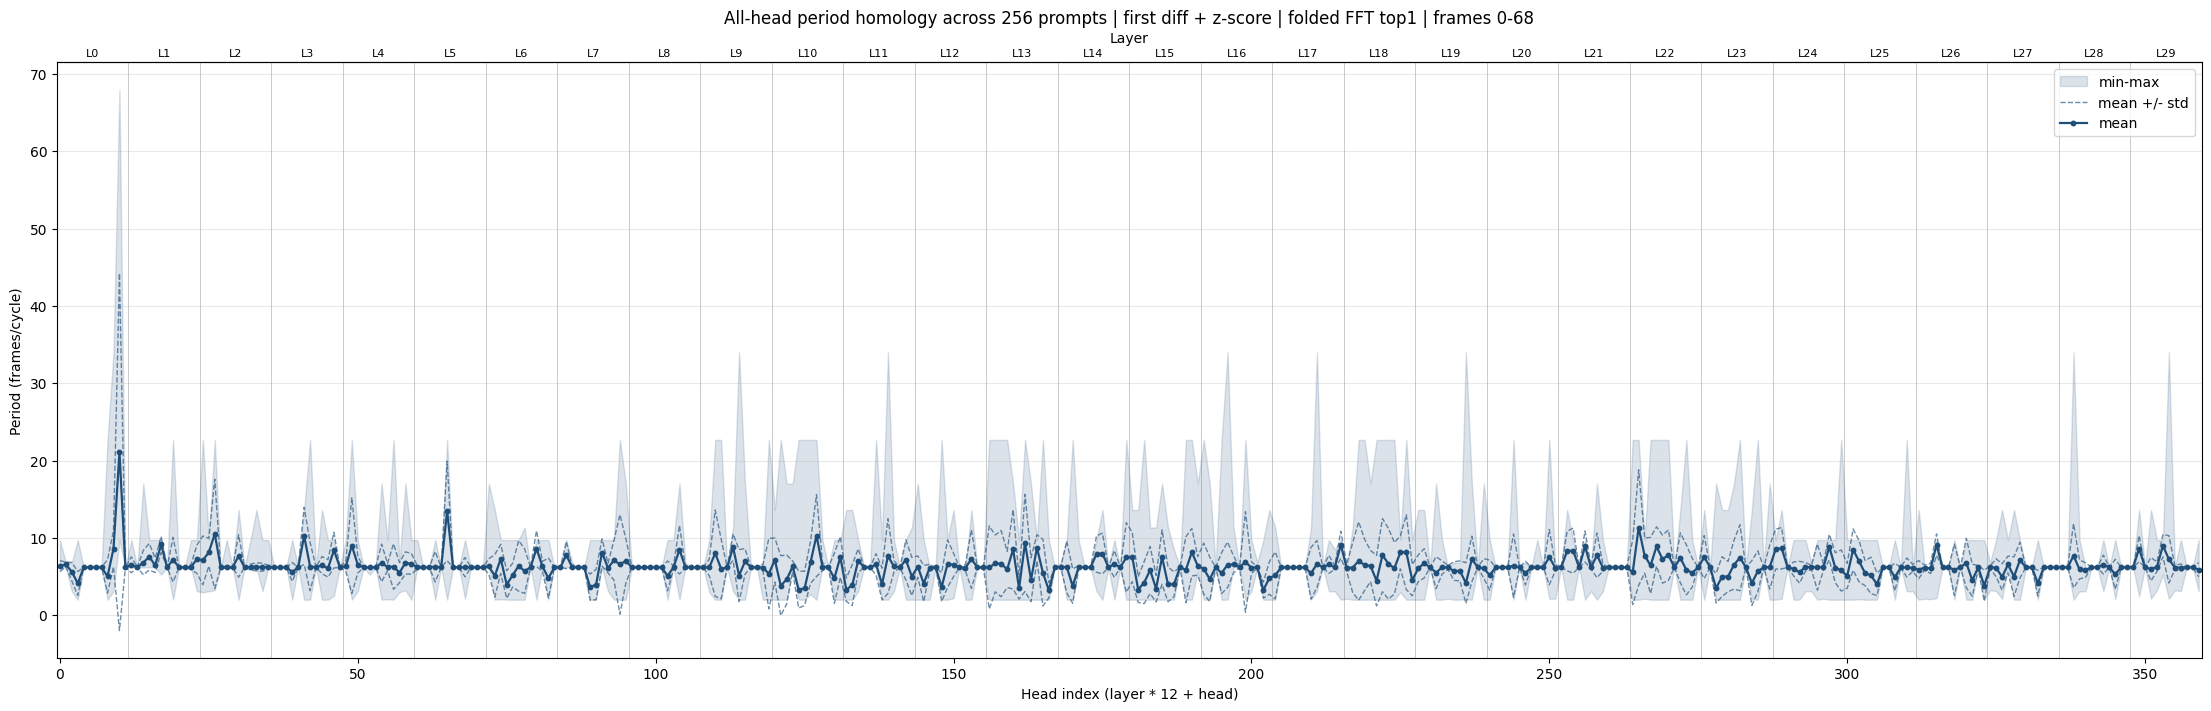

Saved scatter figure to cache/head_period_homology_256_firstdiff_folded_top1_0_68_scatter.png


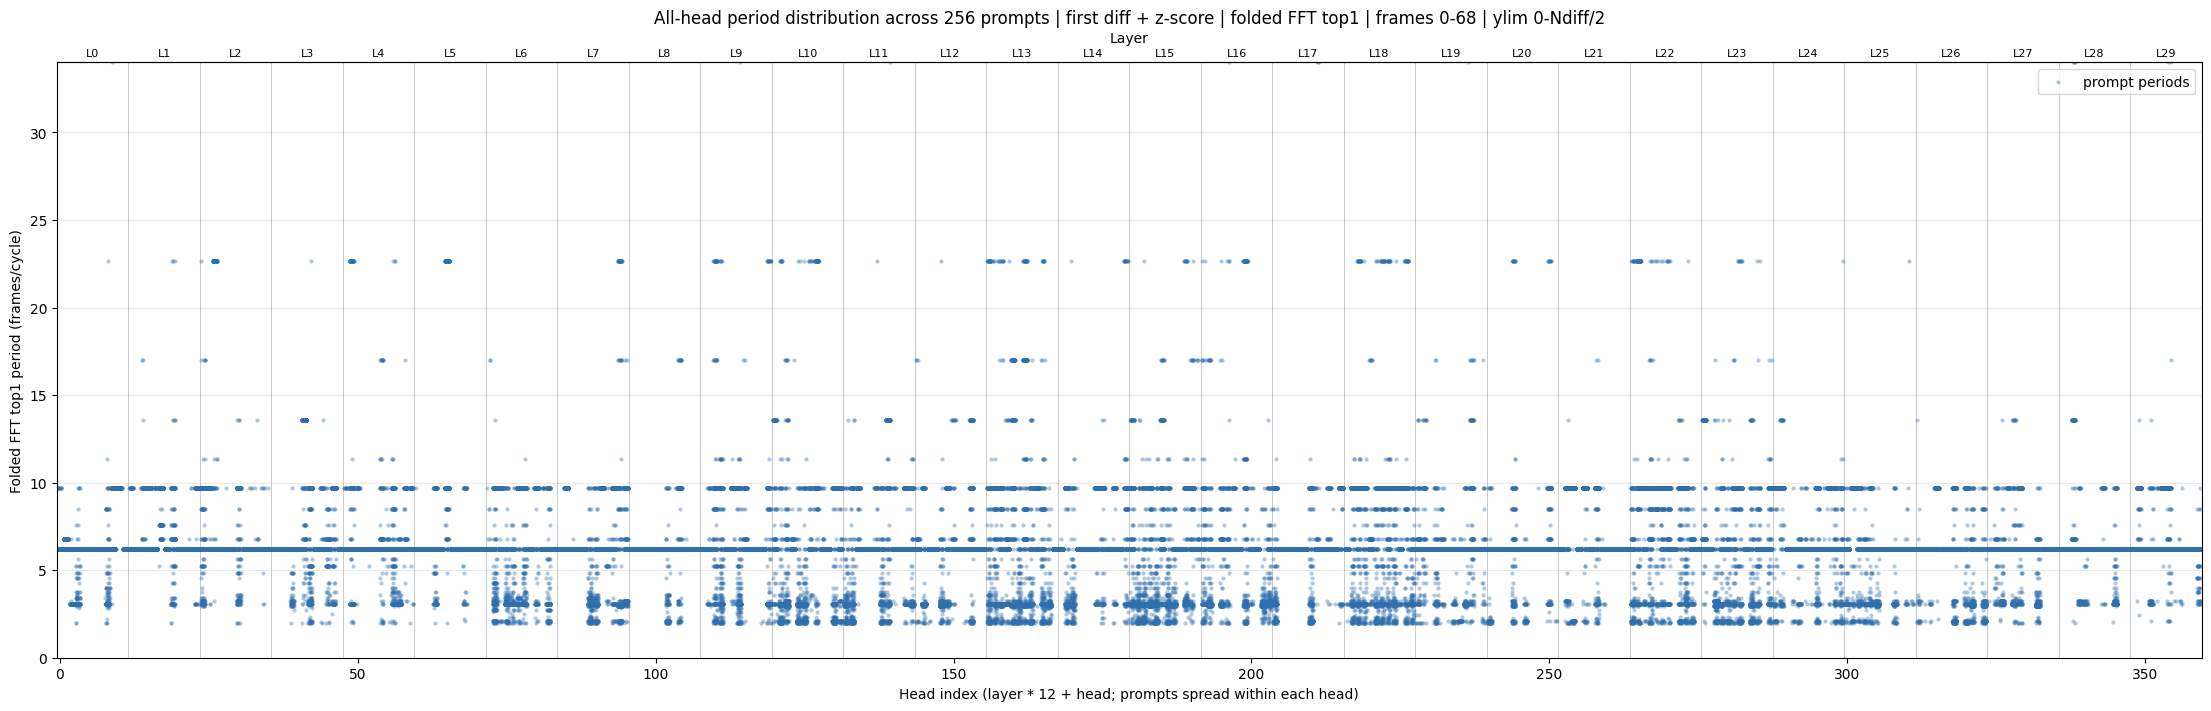

In [111]:
head_period_homology_rows, head_period_homology_errors, head_period_homology_periods = compute_head_period_homology_256()
validate_head_period_homology(
    head_period_homology_rows,
    head_period_homology_errors,
    head_period_homology_periods,
)
write_head_period_homology_csv(head_period_homology_rows)
plot_head_period_homology(head_period_homology_rows, dpi=300)
plot_head_period_homology_scatter(
    head_period_homology_rows,
    head_period_homology_periods,
    dpi=300,
)
